# ¿Hay una relación de largo plazo entre los precios de Bitcoin y la liquidez global? Evidencia de cointegración y Aplicación de VECM

Para evaluarlo, usamos los daots descargados desde trading view. Para mas detalle sobre estas series, acuda al trabajo escrito del estudio

In [1]:
import pandas as pd
import numpy as np


df = pd.read_excel('data/btc_gli.xlsx')
pd.to_datetime(df['date'], errors="coerce")
df = df.drop(columns=["Open", "High", "Low", "Change"], errors="ignore")
df["l_close"] = np.log(df["Close"])
df["l_gli_full"] = np.log(df["gli_full"])
df["l_gli_core"] = np.log(df["gli_core"])
df.head()


,date,Close,gli_full,gli_core,l_close,l_gli_full,l_gli_core
0,23 Feb 2026,64479.0,150.4,30.2,11.074095,5.013298,3.407842
1,16 Feb 2026,67710.0,150.2,30.1,11.122989,5.011968,3.404525
2,09 Feb 2026,68880.0,150.7,30.3,11.140121,5.015291,3.411148
3,02 Feb 2026,70394.0,149.8,30.1,11.161863,5.009301,3.404525
4,26 Jan 2026,77011.0,150.0,30.2,11.251704,5.010635,3.407842


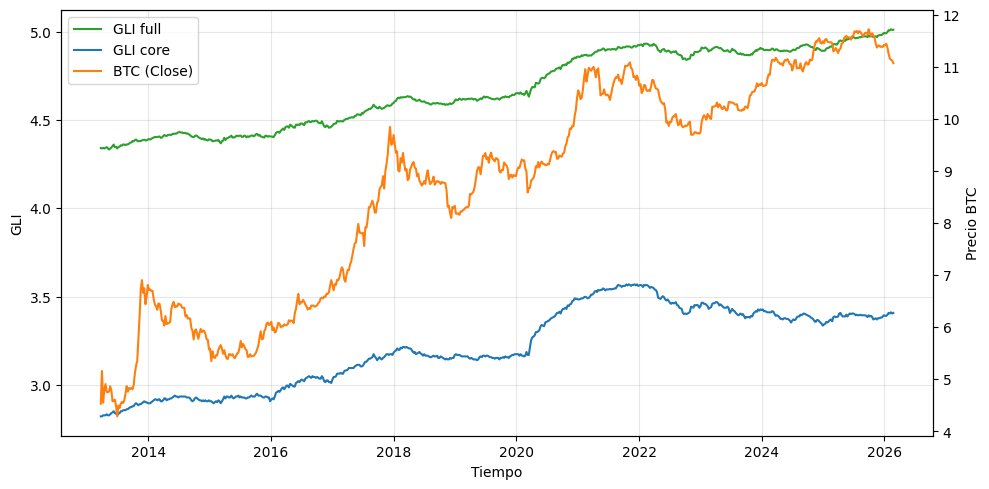

In [2]:
import matplotlib.pyplot as plt

# asegurar fecha + ordenar
_df = df.copy()
_df["date"] = pd.to_datetime(_df["date"], errors="coerce")
_df = _df.dropna(subset=["date"]).sort_values("date")

fig, ax_left = plt.subplots(figsize=(10, 5))

# eje izquierdo: GLI
ax_left.plot(_df["date"], _df["l_gli_full"], label="GLI full", color="tab:green")
ax_left.plot(_df["date"], _df["l_gli_core"], label="GLI core", color="tab:blue")
ax_left.set_ylabel("GLI")
ax_left.set_xlabel("Tiempo")
ax_left.grid(True, alpha=0.3)

# eje derecho: BTC
ax_right = ax_left.twinx()
ax_right.plot(_df["date"], _df["l_close"], label="BTC (Close)", color="tab:orange")
ax_right.set_ylabel("Precio BTC")

# una sola leyenda
lines_l, labels_l = ax_left.get_legend_handles_labels()
lines_r, labels_r = ax_right.get_legend_handles_labels()
ax_left.legend(lines_l + lines_r, labels_l + labels_r, loc="best")

plt.tight_layout()
plt.show()


## Test de raices unitarias

Se procede a realizar los siguientes tests de raices unitarias:
 - Augmented Dickey-Fuller (ADF)
 - Phillips-Perron (PP)
 - KPSS

Previamente:
1) Se importan las librerias econometricas
2) Se importan los warnings para hacer un proper error handling
3) Se copia las series en otras variables, para asegurarnos de no pisar ningun dato
4) Definimos el alpha o significatividad del test en un 5%



In [3]:
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import InterpolationWarning
from arch.unitroot import PhillipsPerron

# trabajar como serie de tiempo
_ts = df.copy()
_ts["date"] = pd.to_datetime(_ts["date"], errors="coerce")
_ts = _ts.dropna(subset=["date"]).sort_values("date").set_index("date")

# por defecto, testear las series en log
cols = ["l_close", "l_gli_full", "l_gli_core"]
if not all(c in _ts.columns for c in cols):
  cols = ["Close", "gli_full", "gli_core"]

alpha = 0.05

### Augmented Dickey-Fuller (ADF)

In [ ]:
# 1) ADF
def adf_p(x, reg="c"):
  x = x.dropna()
  return adfuller(x, regression=reg, autolag="AIC")[1]

rows = []
for c in cols:
  rows.append({
    "serie": c,
    "ADF p (c)": adf_p(_ts[c], reg="c"),
    "ADF p (ct)": adf_p(_ts[c], reg="ct"),
    "ADF p (Δ1)": adf_p(_ts[c].diff(), reg="c"),
  })

adf_df = pd.DataFrame(rows).set_index("serie")
adf_df

,ADF p (c),ADF p (ct),ADF p (Δ1)
serie,,,
l_close,0.442211,0.515328,1.993044e-29
l_gli_full,0.897727,0.512203,9.233052e-09
l_gli_core,0.498929,0.813360,8.911958e-07


- H₀ (ADF): la serie tiene raíz unitaria (no es estacionaria).

- Rechazamos H₀ si p-value < 0.05.
### l_close (log BTC)
#### En niveles
1) ADF (c): 0.442
2) ADF (ct): 0.515
Ambos >> 0.05
- No se rechaza raíz unitaria.
- La serie en niveles es no estacionaria.
#### En primera diferencia
ADF (Δ1): 1.99e-29
- Mucho menor a 0.05
- Se rechaza la hipótesis nula
- Se concluye que la serie diferenciada es estacionaria

Por ende la serie es integrada de primer orden
El análisis es idéntico para las series de liquidez global

La prueba ADF no permite rechazar la hipótesis nula de raíz unitaria en niveles para ninguna de las variables, tanto bajo especificación con constante como con constante y tendencia. Sin embargo, en primeras diferencias la hipótesis nula se rechaza con alta significatividad estadística. En consecuencia, las tres series pueden clasificarse como integradas de orden uno, 𝐼(1)

indica que no hay evidencia fuerte de tendencia determinística estacionaria, sino que la no estacionariedad parece ser genuinamente estocástica (random walk con drift).


### Phillips-Perron (PP)


- H₀ (PP): la serie tiene raíz unitaria (no estacionaria).
- Rechazamos H₀ si p-value < 0.05.

Se confirman las concluciones que en el test ADF

ADF corrige por autocorrelación incluyendo rezagos. PP corrige por heterocedasticidad y autocorrelación no paramétricamente.

Que ambos coincidan indica:

1) No hay problemas de especificación graves.
2) No hay sesgo fuerte por estructura serial.
3) El diagnóstico de 𝐼(1) es robusto.

Esto es exactamente la condición necesaria para aplicar Johansen.

In [5]:
# 2) Phillips-Perron (PP)
# pd.set_option("display.float_format", lambda x: f"{x:.6e}")
def format_p(p):
  if p < 1e-6:
    return "< 1e-6"
  return f"{p:.6f}"
def pp_p(x, trend="c"):
  x = x.dropna()
  pp = PhillipsPerron(x, trend=trend)
  return pp.pvalue

rows = []
for c in cols:
  rows.append({
    "serie": c,
    "PP p (c)": pp_p(_ts[c], trend="c"),
    "PP p (ct)": pp_p(_ts[c], trend="ct"),
    "PP p (Δ1)": pp_p(_ts[c].diff(), trend="c"),
  })

pp_df = pd.DataFrame(rows).set_index("serie")
pp_df

,PP p (c),PP p (ct),PP p (Δ1)
serie,,,
l_close,0.469433,0.375092,0.0
l_gli_full,0.900274,0.694318,0.0
l_gli_core,0.489820,0.943553,0.0


### KPSS

In [6]:
# 3) KPSS (con manejo de warnings por interpolación)
def kpss_p_with_note(x, reg="c"):
  x = x.dropna()

  with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always", InterpolationWarning)
    stat, p, lags, crit = kpss(x, regression=reg, nlags="auto")

  note = ""
  for wi in w:
    msg = str(wi.message)
    if "smaller than the p-value returned" in msg:
      note = "< min tabulado (≈<0.01)"
    elif "greater than the p-value returned" in msg:
      note = "> max tabulado (≈>0.10)"

  return float(p), note

rows = []
for c in cols:
  p_c, note_c = kpss_p_with_note(_ts[c], reg="c")
  p_ct, note_ct = kpss_p_with_note(_ts[c], reg="ct")
  p_d1, note_d1 = kpss_p_with_note(_ts[c].diff(), reg="c")

  rows.append({
    "serie": c,
    "KPSS p (c)": p_c,
    "KPSS note (c)": note_c,
    "KPSS p (ct)": p_ct,
    "KPSS note (ct)": note_ct,
    "KPSS p (Δ1)": p_d1,
    "KPSS note (Δ1)": note_d1,
  })

kpss_df = pd.DataFrame(rows).set_index("serie")
kpss_df

,KPSS p (c),KPSS note (c),KPSS p (ct),KPSS note (ct),KPSS p (Δ1),KPSS note (Δ1)
serie,,,,,,
l_close,0.01,< min tabulado (≈<0.01),0.01,< min tabulado (≈<0.01),0.1,> max tabulado (≈>0.10)
l_gli_full,0.01,< min tabulado (≈<0.01),0.01,< min tabulado (≈<0.01),0.1,> max tabulado (≈>0.10)
l_gli_core,0.01,< min tabulado (≈<0.01),0.01,< min tabulado (≈<0.01),0.1,> max tabulado (≈>0.10)


- H₀ (KPSS): la serie es estacionaria.
- Se rechaza estacionariedad si p-value < 0.05.
Interpretación:
El estadístico es tan grande que el p real es menor que el mínimo tabulado.
Se rechaza fuertemente la hipótesis de estacionariedad.
Tanto con constante como con tendencia.

#### En primeras diferencias
El estadístico es tan pequeño que el p real es mayor que el máximo tabulado.
No se rechaza estacionariedad.
Fuerte evidencia de estacionariedad en diferencias.

En las pruebas de ADF y PP no hay información suficiente para rechazar la hipótesis nula de raíz unitaria en niveles para ninguna de las variables.
En cuanto a la prueba KPSS, se rechaza la hipótesis nula de estacionariedad en niveles.
En primeras diferencias, ADF y PP rechazan raíz unitaria y KPSS no rechaza la hipótesis nula de estacionariedad.
En conjunto, la evidencia es consistente con que las tres series son integradas de orden uno, 𝐼(1).

## Selección del número óptimo de rezagos

Una vez verificado que las series son integradas de orden uno, el siguiente paso consiste en determinar el número óptimo de rezagos del modelo VAR en niveles. Esta decisión es relevante porque el test de cointegración de Johansen y la posterior estimación del VECM dependen de una especificación dinámica adecuada del sistema.

Para ello, se estima un VAR en niveles para el vector de variables endógenas y se selecciona el número de rezagos utilizando criterios de información, principalmente AIC, BIC, HQIC y FPE. Dado que se trabaja con datos semanales, se impone un máximo razonable de rezagos para evitar sobreparametrización y pérdida innecesaria de grados de libertad.

Una vez determinado el número óptimo de rezagos, se procede a aplicar el test de cointegración de Johansen y, en función del rango estimado, a especificar el modelo VECM correspondiente.

In [7]:
from statsmodels.tsa.vector_ar.var_model import VAR

df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).sort_values("date").set_index("date")
# fijar frecuencia semanal lunes (como infiere statsmodels)
df = df.asfreq("W-MON")

# variables del sistema
var_cols = ["l_close", "l_gli_core"]
_ts = _ts.asfreq("W-MON")
var_data = _ts[var_cols].dropna()


# estimación VAR para selección de rezagos
max_lags = 12
var_model = VAR(var_data)

lag_selection = var_model.select_order(maxlags=max_lags)

# mostrar resumen
print(lag_selection.summary())

# tabla con criterios
lag_table = lag_selection.summary()



 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.533      -3.520     0.02921      -3.528
1       -14.33     -14.29*   5.970e-07     -14.32*
2       -14.34      -14.27   5.924e-07      -14.31
3       -14.34      -14.24   5.932e-07      -14.30
4       -14.33      -14.21   5.973e-07      -14.28
5      -14.34*      -14.19  5.905e-07*      -14.28
6       -14.34      -14.16   5.936e-07      -14.27
7       -14.33      -14.12   5.988e-07      -14.25
8       -14.32      -14.09   6.024e-07      -14.23
9       -14.32      -14.07   6.014e-07      -14.22
10      -14.32      -14.03   6.050e-07      -14.21
11      -14.31      -14.00   6.117e-07      -14.19
12      -14.30      -13.96   6.138e-07      -14.17
--------------------------------------------------


La tabla reporta los valores de distintos criterios de información para seleccionar el número óptimo de rezagos del modelo VAR. Cada fila corresponde a un posible orden del VAR, desde 0 hasta 12 rezagos, mientras que las columnas muestran los valores de los criterios AIC (Akaike Information Criterion), BIC (Bayesian Information Criterion), FPE (Final Prediction Error) y HQIC (Hannan–Quinn Information Criterion). En todos los casos, el rezago óptimo se identifica por el valor mínimo del criterio correspondiente, indicado con un asterisco. Los resultados muestran que los criterios AIC y FPE alcanzan su mínimo en seis rezagos, mientras que los criterios BIC y HQIC lo hacen en un rezago. Esto refleja el comportamiento típico de estos criterios: AIC y FPE tienden a seleccionar modelos más complejos, mientras que BIC y HQIC penalizan con mayor intensidad la inclusión de parámetros adicionales y favorecen especificaciones más parsimoniosas.

Siguiendo la práctica habitual en la literatura de cointegración, se adopta la especificación sugerida por los criterios BIC y HQIC, que penalizan en mayor medida la complejidad del modelo. En consecuencia, se selecciona un modelo VAR(1) en niveles como base para el análisis posterior. Dado que el modelo VECM se deriva del VAR en niveles, esta elección implica que la representación VECM incluirá 𝑝−1=0 rezagos en primeras diferencias.

1 seleccion rezagos de var
2 test de countegraciopn de johjansemn trace test y maximum eigenvalue test
modelo


## Test de cointegración de Johansen

Si se encuentra al menos un vector cointegrante (r>0), ello implica que existe una combinación lineal de las variables del sistema que es estacionaria.

En términos económicos, esto significa que, aunque el precio de Bitcoin y la liquidez global puedan desviarse entre sí en el corto plazo, existe una relación de equilibrio de largo plazo que limita dichas desviaciones.

In [8]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# variables del sistema
johansen_data = var_data

# johansen test
johansen_test = coint_johansen(
    johansen_data,
    det_order=0,   # constante en cointegración
    k_ar_diff=0    # p-1 = 0 porque VAR(1)
)

print("Eigenvalues")
print(johansen_test.eig)

print("Trace statistic")
print(johansen_test.lr1)

print("Critical values (trace)")
print(johansen_test.cvt)

print("Max eigen statistic")
print(johansen_test.lr2)

print("Critical values (max eigen)")
print(johansen_test.cvm)

Eigenvalues
[0.0096519  0.00137907]
Trace statistic
[7.4671114  0.93013417]
Critical values (trace)
[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max eigen statistic
[6.53697723 0.93013417]
Critical values (max eigen)
[[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [10]:

trace = johansen_test.lr1
trace_cv = johansen_test.cvt[:,1]   # columna 5%

maxeig = johansen_test.lr2
maxeig_cv = johansen_test.cvm[:,1]

table = pd.DataFrame({
  "Hypothesis": ["r = 0", "r ≤ 1"],
  "Trace statistic": trace,
  "Trace CV (5%)": trace_cv,
  "Max eigen statistic": maxeig,
  "Max eigen CV (5%)": maxeig_cv
})

table.round(3)

,Hypothesis,Trace statistic,Trace CV (5%),Max eigen statistic,Max eigen CV (5%)
0,r = 0,7.467,15.494,6.537,14.264
1,r ≤ 1,0.930,3.842,0.930,3.842


No se puede rechazar la hipótesis nula en ninguno de los dos tests. Por lo que se concluye que no hay evidencia empirica de co integración en la muestra utilizada

## VAR en diferencias

Ante la ausencia de una relación de largo plazo entre las series, se procede a calcular un var en primeras diferencias para captar la relación de corto plazo

### Se construyen las series en primeras diferencias

In [45]:
# primeras diferencias
var_data = _ts[var_cols].dropna().asfreq("W-MON")

# primeras diferencias
dvar_data = var_data.diff().dropna().copy()
dvar_data.columns = ["d_l_close", "d_l_gli_core"]

### Selección de rezagos para el VAR en diferencias

In [46]:
# 3. selección de rezagos
var_diff_model = VAR(dvar_data)
lag_selection_diff = var_diff_model.select_order(maxlags=12)

print(lag_selection_diff.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -14.33     -14.32*   5.975e-07     -14.33*
1       -14.34      -14.30   5.932e-07      -14.32
2       -14.34      -14.27   5.935e-07      -14.31
3       -14.33      -14.24   5.974e-07      -14.29
4      -14.34*      -14.22  5.901e-07*      -14.30
5       -14.34      -14.19   5.930e-07      -14.28
6       -14.33      -14.15   5.986e-07      -14.26
7       -14.32      -14.12   6.019e-07      -14.24
8       -14.32      -14.09   6.012e-07      -14.23
9       -14.32      -14.06   6.045e-07      -14.22
10      -14.31      -14.02   6.117e-07      -14.20
11      -14.30      -13.99   6.142e-07      -14.18
12      -14.30      -13.97   6.130e-07      -14.17
--------------------------------------------------


Se observan dos confluencias en los resultados, con 0 lags para los criterios BIC y HQIC, y de 4 lags para AIC y FPE.
Esto es un patrón común ya que el BIC y HQIC tienden a sugerir modelos mas parsimoniosos, pero econometricamente no tiene mucho análisis elegir un var en diferencias de orden 0 porque esto sugiere que no hay una dinámica entre las variables sino que es sólo un ruido blanco.

In [47]:
p = lag_selection_diff.aic   # o .hqic, .aic, bic
# o definir p manualmente:
# p = 4

var_fit = var_diff_model.fit(p)

print(var_fit.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 18, Mar, 2026
Time:                     20:18:38
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.2220
Nobs:                     670.000    HQIC:                  -14.2962
Log likelihood:           2921.55    FPE:                5.90039e-07
AIC:                     -14.3431    Det(Omega_mle):     5.74501e-07
--------------------------------------------------------------------
Results for equation d_l_close
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.006760         0.004009            1.686           0.092
L1.d_l_close            0.095750         0.039086            2.450           0.014
L1.d_l_gli_core        -0.471740         0.51314

In [48]:
# estabilidad
var_fit.is_stable(verbose=True)

# raíces del sistema
np.abs(var_fit.roots)

Eigenvalues of VAR(1) rep
0.6615498748196528
0.387432053251077
0.387432053251077
0.4467831823673516
0.4467831823673516
0.6280487677447012
0.6280487677447012
0.5674013940968131


array([2.58109775, 2.58109775, 2.23822212, 2.23822212, 1.76242077,
       1.59223304, 1.59223304, 1.51160183])

In [49]:
whiteness = var_fit.test_whiteness(nlags=12)
print(whiteness.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         34.93          46.19   0.330 32
----------------------------------------


### Diagnóstico del modelo VAR

Como paso previo al análisis dinámico, se evaluaron las condiciones de estabilidad del modelo VAR(4) estimado en primeras diferencias. Los resultados muestran que todos los autovalores del sistema se encuentran dentro del círculo unitario, lo que garantiza la estabilidad del modelo y la validez de su representación dinámica.

Adicionalmente, se analizó la presencia de autocorrelación en los residuos mediante el test de Portmanteau. Los resultados no permiten rechazar la hipótesis nula de ausencia de autocorrelación hasta el rezago 12 (p-value = 0.330), lo que sugiere que el modelo captura adecuadamente la dinámica temporal de las variables y no presenta problemas de especificación.

En conjunto, estos resultados validan el uso del VAR(4) como base para el análisis de causalidad de Granger y funciones impulso–respuesta.

## Causalidad de Granger

In [51]:
# GLI → BTC

granger_gli_to_btc = var_fit.test_causality(
  caused="d_l_close",
  causing=["d_l_gli_core"],
  kind="f"
)

print(granger_gli_to_btc.summary())

# BTC → GLI
granger_btc_to_gli = var_fit.test_causality(
  caused="d_l_gli_core",
  causing=["d_l_close"],
  kind="f"
)

print(granger_btc_to_gli.summary())

Granger causality F-test. H_0: d_l_gli_core does not Granger-cause d_l_close. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
         1.236          2.379   0.294 (4, np.int64(1322))
---------------------------------------------------------
Granger causality F-test. H_0: d_l_close does not Granger-cause d_l_gli_core. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df        
---------------------------------------------------------
       0.04822          2.379   0.996 (4, np.int64(1322))
---------------------------------------------------------


Para la dirección GLI → BTC 
todos los rezagos de Δln(GLIt) son conjuntamente nulos en la ecuación de Δln(𝐵𝑇𝐶𝑡).
y análogamente, para BTC → GLI

### Función impulso-rspuesta (IRF)

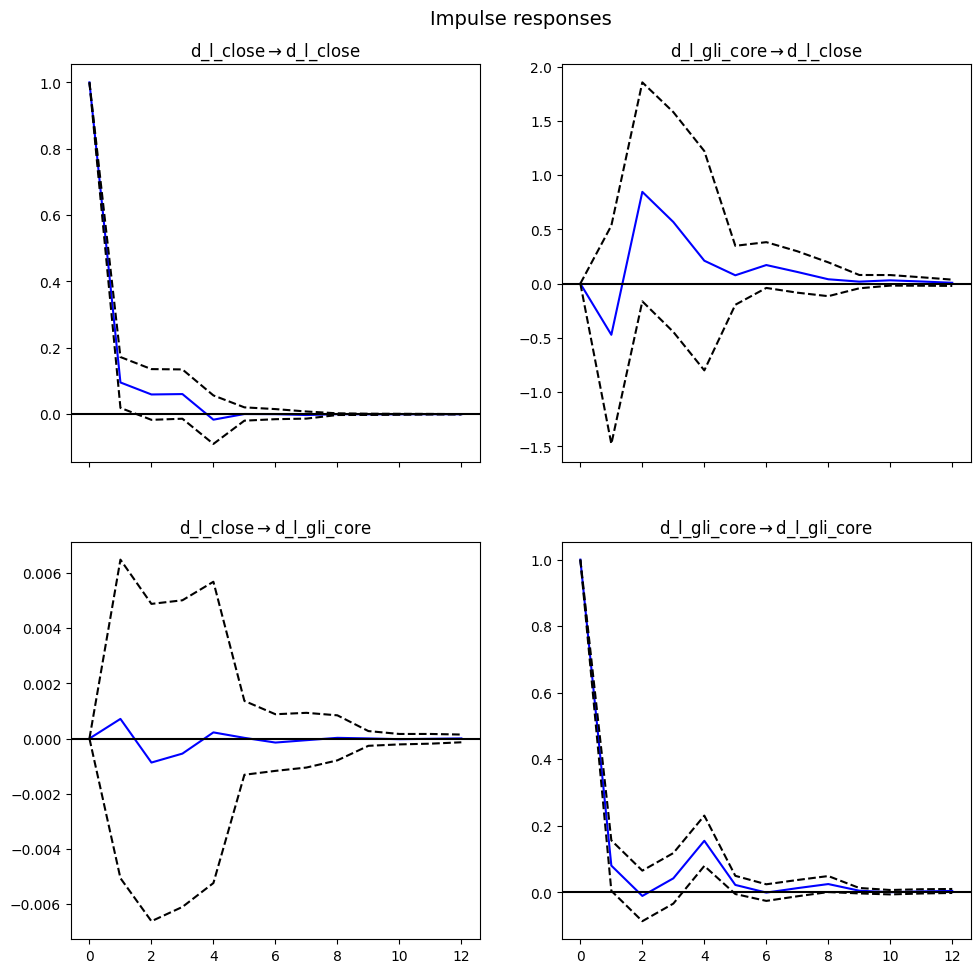

In [52]:
import matplotlib.pyplot as plt

# horizonte de 12 semanas
irf = var_fit.irf(12)

# 1) Gráfico general de todas las respuestas
irf.plot()
plt.show()

Las funciones impulso–respuesta confirman que la dinámica del sistema es predominantemente transitoria. Los shocks propios, tanto en Bitcoin como en la liquidez global, generan respuestas positivas de corto plazo que convergen rápidamente a cero, lo que resulta consistente con la estabilidad del VAR estimado. En cuanto a los efectos cruzados, un shock en la liquidez global produce una respuesta positiva y transitoria en el precio de Bitcoin, con un pico alrededor de las semanas 2 y 3; sin embargo, los intervalos de confianza incluyen el cero a lo largo del horizonte considerado, por lo que el efecto no puede considerarse estadísticamente robusto. En sentido inverso, los shocks en Bitcoin no generan respuestas relevantes en la liquidez global. En conjunto, estos resultados refuerzan la idea de que la relación entre ambas variables es débil, de corto plazo y sin evidencia de un mecanismo sistemático de transmisión.

### Análisis de robustez: especificación alternativa del VAR
Dado que la selección del número de rezagos para el VAR en primeras diferencias arrojó resultados mixtos entre los distintos criterios de información, resulta conveniente complementar el análisis con una especificación alternativa más parsimoniosa. Este ejercicio de robustez permite evaluar si los resultados principales del modelo base —en particular, la ausencia de causalidad de Granger robusta y la debilidad de las respuestas impulso–respuesta— dependen críticamente de haber utilizado cuatro rezagos o si, por el contrario, se mantienen bajo una estructura dinámica más simple.
En este contexto, se estima un VAR(1) en primeras diferencias como especificación alternativa. La comparación entre ambos modelos permite verificar la estabilidad cualitativa de los resultados y fortalecer la interpretación empírica del trabajo.


In [58]:
# -----------------------------
# Robustness check: VAR(1)
# -----------------------------
p = 1

var_fit_1 = var_diff_model.fit(p)

print(var_fit_1.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Wed, 18, Mar, 2026
Time:                     23:04:32
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -14.2325
Nobs:                     673.000    HQIC:                  -14.2571
Log likelihood:           2898.87    FPE:                6.33056e-07
AIC:                     -14.2727    Det(Omega_mle):     6.27450e-07
--------------------------------------------------------------------
Results for equation d_l_close
                     coefficient       std. error           t-stat            prob
----------------------------------------------------------------------------------
const                   0.008734         0.004060            2.151           0.031
L1.d_l_close            0.025345         0.037808            0.670           0.503
L1.d_l_gli_core        -0.226789         0.52830

#### Diagnóstico de estabilidad

In [59]:
# estabilidad
var_fit_1.is_stable(verbose=True)

# autovalores
import numpy as np
np.abs(var_fit_1.roots)

Eigenvalues of VAR(1) rep
0.032999234923420905
0.07708927743599947


array([30.30373287, 12.97197267])

In [60]:
whiteness_1 = var_fit_1.test_whiteness(nlags=12)
print(whiteness_1.summary())

Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         74.83          60.48   0.003 44
----------------------------------------


In [62]:
# GLI → BTC
granger_gli_to_btc_1 = var_fit_1.test_causality(
  caused="d_l_close",
  causing=["d_l_gli_core"],
  kind="f"
)
print(granger_gli_to_btc_1.summary())

# BTC → GLI
granger_btc_to_gli_1 = var_fit_1.test_causality(
  caused="d_l_gli_core",
  causing=["d_l_close"],
  kind="f"
)
print(granger_btc_to_gli_1.summary())

Granger causality F-test. H_0: d_l_gli_core does not Granger-cause d_l_close. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.1843          3.848   0.668 (1, 1340)
-----------------------------------------------
Granger causality F-test. H_0: d_l_close does not Granger-cause d_l_gli_core. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value     df   
-----------------------------------------------
        0.3988          3.848   0.528 (1, 1340)
-----------------------------------------------


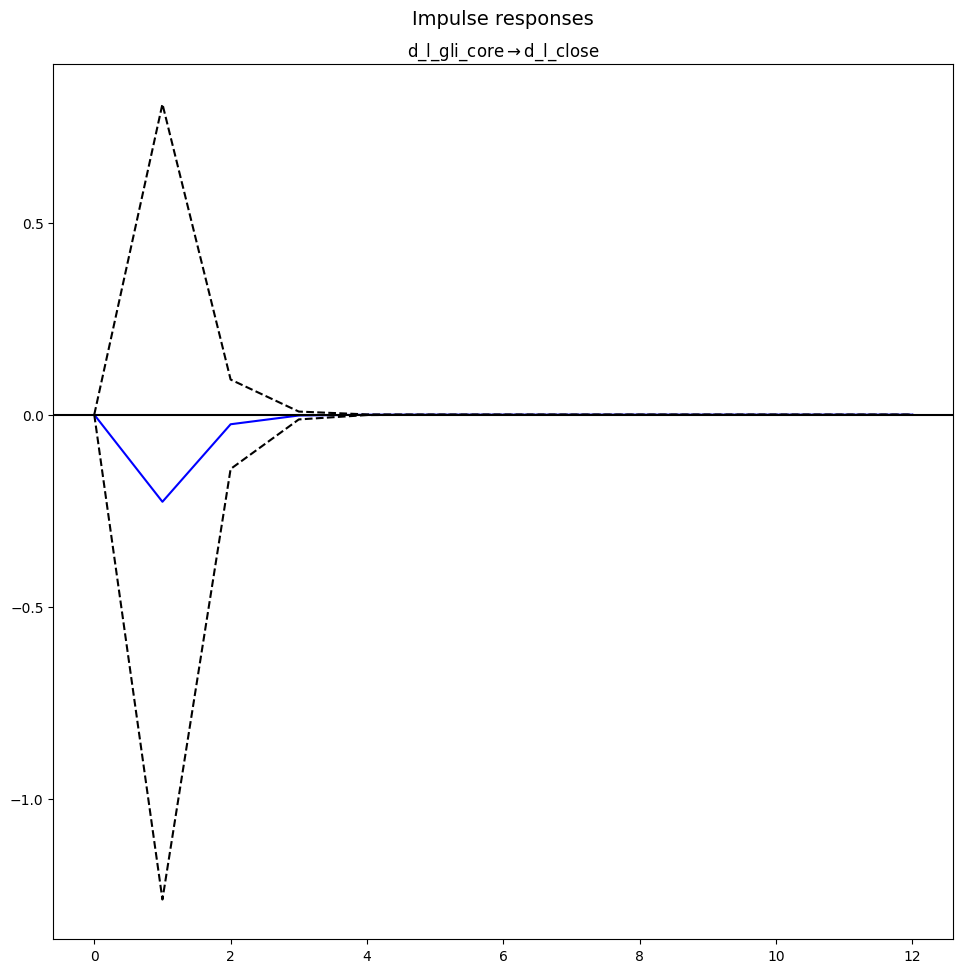

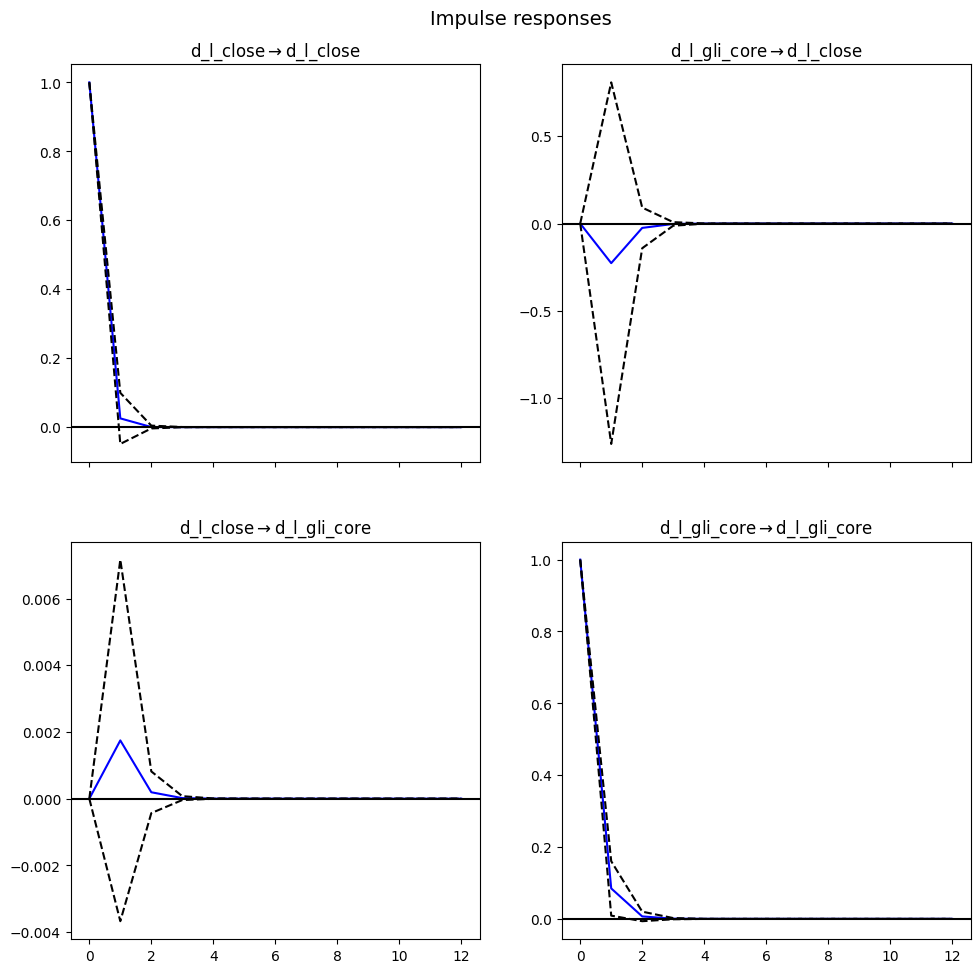

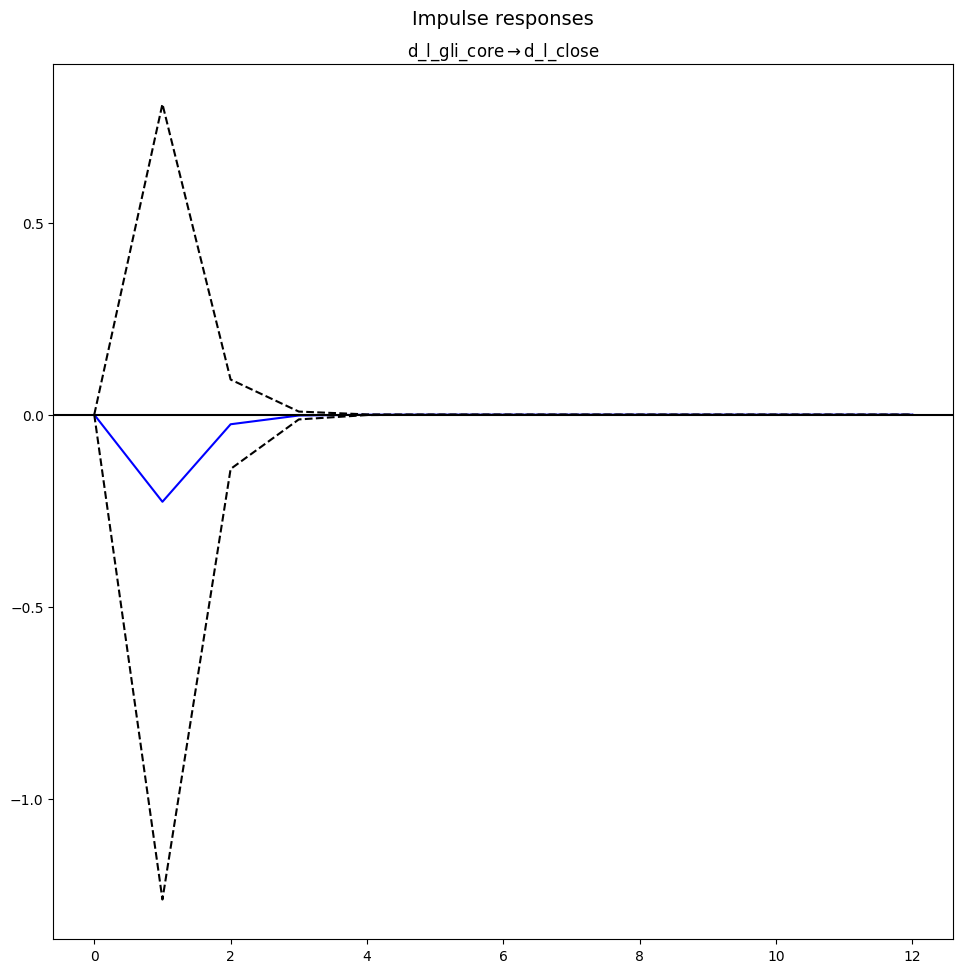

In [64]:
irf_1 = var_fit_1.irf(12)

# gráfico general
irf_1.plot()

# respuesta de BTC a shock en GLI
irf_1.plot(impulse="d_l_gli_core", response="d_l_close")